# 03 — Détection des Anomalies et Fuites
## Projet PFE : Système Intelligent de Gestion de l'Eau — Grand Agadir

**3 modèles comparés :**
| Modèle | Type | Librairie |
|---|---|---|
| Isolation Forest | Détection d'outliers par isolation | scikit-learn |
| LSTM-Autoencoder | Deep Learning — reconstruction d'erreur | tensorflow/keras |
| Méthode 3-sigma | Statistique robuste sur résidus STL | statsmodels |

**Métriques de comparaison :** Précision / Rappel / F1-Score / AUC-ROC + Matrice de confusion  
**Vérité terrain :** colonne `anomaly_label` (`normal` / `anomaly` / `leak`)  
**Stratégie :** binaire (`normal` vs `anomaly+leak`) ET multiclasse (`normal` / `anomaly` / `leak`)

---


## 0. Imports & Configuration

In [1]:
import sys
!{sys.executable} -m pip install scikit-learn tensorflow statsmodels --quiet
print('✅ Dépendances installées')

✅ Dépendances installées



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import warnings
warnings.filterwarnings('ignore')
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import joblib

# ── Modèles & métriques ──────────────────────────────────────────────────────
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from statsmodels.tsa.seasonal import STL
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, RepeatVector, TimeDistributed
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ── Style (identique aux notebooks 01 et 02) ─────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (14, 5)})

# ── Chemins ───────────────────────────────────────────────────────────────────
DATA_DIR  = Path('../data')
MODEL_DIR = Path('../models')
FIG_DIR   = Path('../reports/figures')
MODEL_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

np.random.seed(42)
tf.random.set_seed(42)

# Couleurs cohérentes avec les notebooks précédents
COLORS = {
    'normal':   '#4E79A7',
    'anomaly':  '#F28E2B',
    'leak':     '#E15759',
    'if':       '#4E79A7',
    'lstm_ae':  '#9B59B6',
    'sigma3':   '#59A14F',
}

print('✅ Imports OK')
print(f'   TensorFlow : {tf.__version__}')

✅ Imports OK
   TensorFlow : 2.21.0


## 1. Chargement & Préparation des Données

In [3]:
# ── Chargement (même dataset que les notebooks 01 et 02) ─────────────────────
df_train = pd.read_csv(DATA_DIR / 'train.csv', parse_dates=['timestamp'])
df_test  = pd.read_csv(DATA_DIR / 'test.csv',  parse_dates=['timestamp'])

# ── Normalisation des noms de colonnes (cohérence avec notebook 01) ───────────
for _df in [df_train, df_test]:
    _df.columns = _df.columns.str.strip().str.lower()

# Concaténer pour la détection d'anomalies (on évalue sur tout)
df_all = pd.concat([df_train, df_test]).sort_values(['meterid', 'timestamp']).reset_index(drop=True)

print(f'Train : {len(df_train):,} lignes  ({df_train.timestamp.min().date()} → {df_train.timestamp.max().date()})')
print(f'Test  : {len(df_test):,} lignes   ({df_test.timestamp.min().date()} → {df_test.timestamp.max().date()})')
print(f'Total : {len(df_all):,} lignes')
print(f'\nColonnes ({len(df_all.columns)}) : {list(df_all.columns)}')

Train : 224,640 lignes  (2025-02-01 → 2025-08-14)
Test  : 52,992 lignes   (2025-08-15 → 2025-09-29)
Total : 277,632 lignes

Colonnes (19) : ['timestamp', 'meterid', 'zone', 'quartier', 'latitude', 'longitude', 'consumptionliters', 'flowratelpm', 'pressurebar', 'temperaturec', 'hour', 'dayofweek', 'month', 'isweekend', 'season', 'household_size', 'event_type', 'anomalylabel', 'temp_bin']


In [4]:
# ── Vérification de la vérité terrain ────────────────────────────────────────
# Nom de la colonne label (anomalylabel dans ce dataset)
LABEL_COL = 'anomalylabel'
assert LABEL_COL in df_all.columns, (
    f"Colonne '{LABEL_COL}' introuvable. Colonnes disponibles : {list(df_all.columns)}"
)

print('=== DISTRIBUTION DES LABELS (vérité terrain) ===')
label_counts = df_all[LABEL_COL].value_counts()
label_pcts   = df_all[LABEL_COL].value_counts(normalize=True) * 100

for label in label_counts.index:
    print(f'  {label:<10} : {label_counts[label]:>7,} ({label_pcts[label]:.2f}%)')

print(f"\n  Taux d'anomalie total : {(label_pcts.get('anomaly', 0) + label_pcts.get('leak', 0)):.2f}%")

=== DISTRIBUTION DES LABELS (vérité terrain) ===
  normal     : 266,504 (95.99%)
  anomaly    :   6,972 (2.51%)
  leak       :   4,156 (1.50%)

  Taux d'anomalie total : 4.01%


In [5]:
# ── Encodage des labels ───────────────────────────────────────────────────────
# Binaire : 0=normal, 1=anomalie/fuite (pour IF et 3-sigma)
df_all['label_binary'] = (df_all[LABEL_COL] != 'normal').astype(int)

# Multiclasse : 0=normal, 1=anomaly, 2=leak
label_map = {'normal': 0, 'anomaly': 1, 'leak': 2}
df_all['label_multi'] = df_all[LABEL_COL].map(label_map)

print('✅ Labels encodés')
print(f'  Binaire     — 0: {(df_all.label_binary == 0).sum():,}  |  1: {(df_all.label_binary == 1).sum():,}')
print(f'  Multiclasse — 0: {(df_all.label_multi == 0).sum():,}  |  1: {(df_all.label_multi == 1).sum():,}  |  2: {(df_all.label_multi == 2).sum():,}')

✅ Labels encodés
  Binaire     — 0: 266,504  |  1: 11,128
  Multiclasse — 0: 266,504  |  1: 6,972  |  2: 4,156


In [6]:
# ── Features pour la détection (communes aux 3 modèles) ──────────────────────
# rainfall absent du dataset → features disponibles
DETECTION_FEATURES = ['consumptionliters', 'flowratelpm', 'pressurebar', 'temperaturec']

# Ajouter lags par compteur (utile pour IF et LSTM-AE)
df_feat = df_all.copy()
for lag in [1, 2, 3, 24]:
    df_feat[f'lag_{lag}'] = df_feat.groupby('meterid')['consumptionliters'].shift(lag)

# Moyenne glissante 24h (par compteur)
df_feat['roll_mean_24'] = df_feat.groupby('meterid')['consumptionliters'].transform(
    lambda x: x.shift(1).rolling(24, min_periods=1).mean()
)
df_feat['roll_std_24'] = df_feat.groupby('meterid')['consumptionliters'].transform(
    lambda x: x.shift(1).rolling(24, min_periods=1).std().fillna(0)
)

# Écart à la moyenne glissante (signal de fuite)
df_feat['deviation'] = df_feat['consumptionliters'] - df_feat['roll_mean_24']
df_feat['deviation_ratio'] = np.where(
    df_feat['roll_mean_24'] > 0,
    df_feat['deviation'] / df_feat['roll_mean_24'],
    0
)

# Features étendues pour Isolation Forest
IF_FEATURES = DETECTION_FEATURES + ['lag_1', 'lag_24', 'roll_mean_24', 'roll_std_24', 'deviation_ratio']
IF_FEATURES = [f for f in IF_FEATURES if f in df_feat.columns]

# Supprimer les NaN (crées par les lags)
df_feat = df_feat.dropna(subset=IF_FEATURES).reset_index(drop=True)

print(f'✅ Features créées : {IF_FEATURES}')
print(f'   Shape après dropna : {df_feat.shape}')

✅ Features créées : ['consumptionliters', 'flowratelpm', 'pressurebar', 'temperaturec', 'lag_1', 'lag_24', 'roll_mean_24', 'roll_std_24', 'deviation_ratio']
   Shape après dropna : (277344, 29)


In [7]:
# ── Fonction d'évaluation (partagée par les 3 modèles) ───────────────────────
def evaluate_detector(y_true, y_pred_binary, model_name, pos_label=1):
    """
    Calcule et affiche Précision / Rappel / F1 + matrice de confusion.
    Retourne un dict avec les métriques.
    """
    prec = precision_score(y_true, y_pred_binary, zero_division=0)
    rec  = recall_score(y_true, y_pred_binary, zero_division=0)
    f1   = f1_score(y_true, y_pred_binary, zero_division=0)
    
    print(f'\n📊 {model_name}')
    print(f'   Précision : {prec:.4f}  ({prec*100:.1f}%)')
    print(f'   Rappel    : {rec:.4f}  ({rec*100:.1f}%)')
    print(f'   F1-Score  : {f1:.4f}')
    print()
    print(classification_report(y_true, y_pred_binary, target_names=['Normal', 'Anomalie']))
    
    return {'model': model_name, 'Précision': prec, 'Rappel': rec, 'F1': f1}

# Résultats de tous les modèles
results_detection = []
print('✅ Fonction evaluate_detector prête')

✅ Fonction evaluate_detector prête


## 2. Modèle 1 — Isolation Forest

**Principe :** Isole les points anormaux en les coupant aléatoirement dans l'espace des features.  
Un point est anormal si on l'isole avec **peu de coupures** (il est rare et éloigné du reste).  
- `contamination` : fraction attendue d'anomalies (≈ 4% d'après notre EDA)  
- Rapide, non-paramétrique, pas d'hypothèse sur la distribution


In [8]:
# ── Normalisation des features ────────────────────────────────────────────────
scaler_if = MinMaxScaler()

X_if = df_feat[IF_FEATURES].values
X_if_sc = scaler_if.fit_transform(X_if)
y_true_if = df_feat['label_binary'].values

print(f'✅ Données IF prêtes : {X_if_sc.shape}')
print(f'   Features utilisées : {IF_FEATURES}')
print(f'   Taux réel d\'anomalies : {y_true_if.mean():.4f} ({y_true_if.mean()*100:.2f}%)')

✅ Données IF prêtes : (277344, 9)
   Features utilisées : ['consumptionliters', 'flowratelpm', 'pressurebar', 'temperaturec', 'lag_1', 'lag_24', 'roll_mean_24', 'roll_std_24', 'deviation_ratio']
   Taux réel d'anomalies : 0.0401 (4.01%)


In [9]:
# ── Entraînement Isolation Forest ────────────────────────────────────────────
print('⏳ Entraînement Isolation Forest...')

# Contamination calée sur le taux réel d'anomalies du dataset
CONTAMINATION = round(float(y_true_if.mean()), 4)

model_if = IsolationForest(
    n_estimators=200,
    contamination=CONTAMINATION,
    max_samples='auto',
    random_state=42,
    n_jobs=-1
)

# Entraîner uniquement sur les données TRAIN (pas de fuite)
X_train_if = df_feat[df_feat['timestamp'] < df_test['timestamp'].min()][IF_FEATURES].values
X_train_if_sc = scaler_if.transform(X_train_if)
model_if.fit(X_train_if_sc)

print(f'✅ Isolation Forest entraîné ({model_if.n_estimators} arbres, contamination={CONTAMINATION})')

⏳ Entraînement Isolation Forest...
✅ Isolation Forest entraîné (200 arbres, contamination=0.0401)


In [10]:
# ── Prédiction Isolation Forest ──────────────────────────────────────────────
# predict() retourne +1 (normal) ou -1 (anomalie)
raw_pred_if = model_if.predict(X_if_sc)
y_pred_if   = (raw_pred_if == -1).astype(int)  # 1 = anomalie

# Score d'anomalie (plus négatif = plus anormal)
scores_if = -model_if.score_samples(X_if_sc)  # on inverse pour que haut = anormal

metrics_if = evaluate_detector(y_true_if, y_pred_if, 'Isolation Forest')
results_detection.append(metrics_if)


📊 Isolation Forest
   Précision : 0.3108  (31.1%)
   Rappel    : 0.4090  (40.9%)
   F1-Score  : 0.3532

              precision    recall  f1-score   support

      Normal       0.97      0.96      0.97    266221
    Anomalie       0.31      0.41      0.35     11123

    accuracy                           0.94    277344
   macro avg       0.64      0.69      0.66    277344
weighted avg       0.95      0.94      0.94    277344



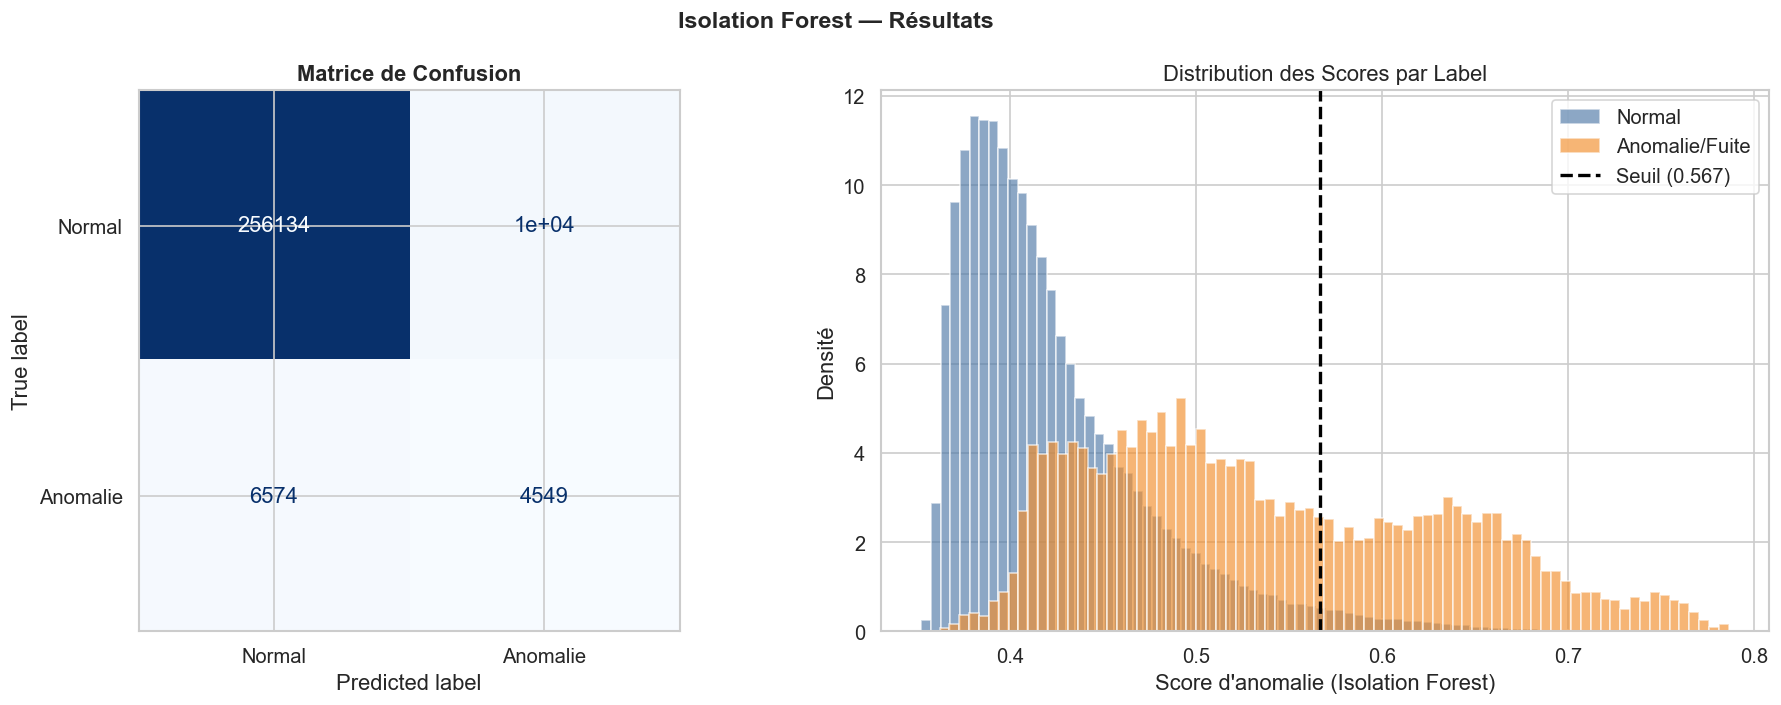

In [11]:
# ── Visualisation Isolation Forest ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Isolation Forest — Résultats', fontsize=14, fontweight='bold')

# --- Matrice de confusion ---
ax = axes[0]
cm = confusion_matrix(y_true_if, y_pred_if)
disp = ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Anomalie'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Matrice de Confusion', fontweight='bold')

# --- Distribution des scores par label ---
ax = axes[1]
ax.hist(scores_if[y_true_if == 0], bins=80, alpha=0.65,
        color=COLORS['normal'], label='Normal', density=True)
ax.hist(scores_if[y_true_if == 1], bins=80, alpha=0.65,
        color=COLORS['anomaly'], label='Anomalie/Fuite', density=True)
thresh = np.percentile(scores_if, (1 - CONTAMINATION) * 100)
ax.axvline(thresh, color='black', lw=2, ls='--', label=f'Seuil ({thresh:.3f})')
ax.set_xlabel("Score d'anomalie (Isolation Forest)")
ax.set_ylabel('Densité')
ax.set_title('Distribution des Scores par Label')
ax.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig31_isolation_forest_resultats.png', bbox_inches='tight')
plt.show()

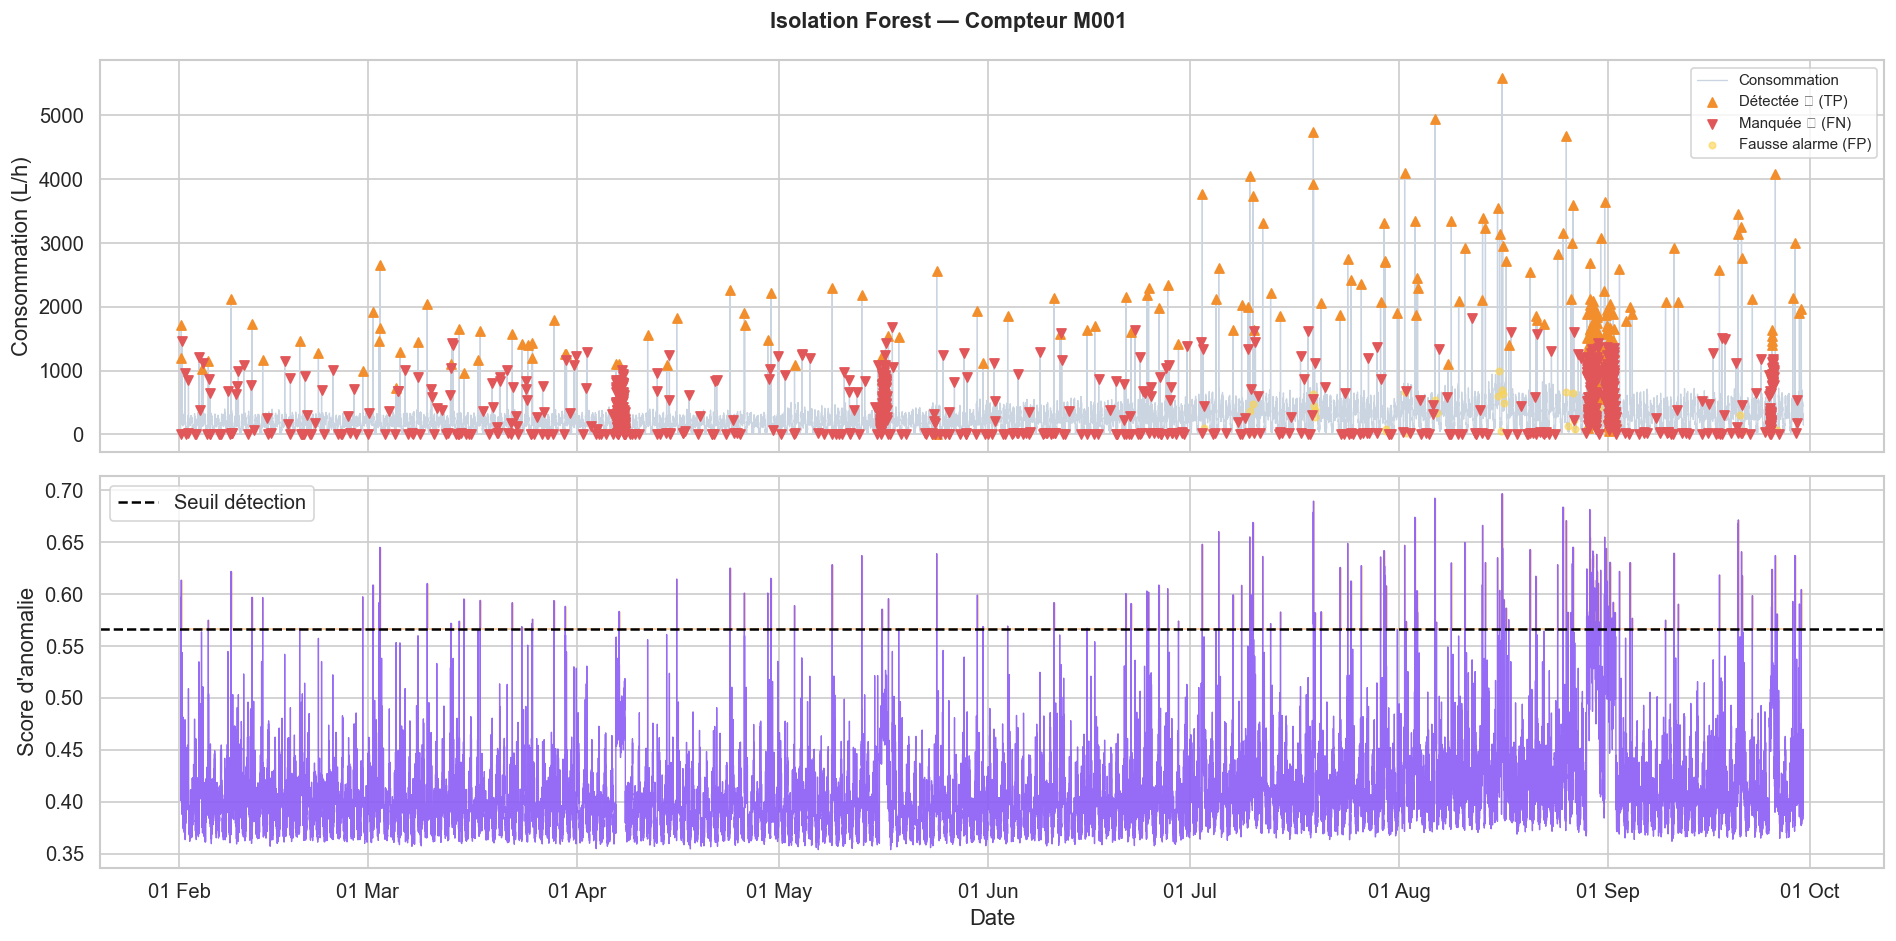

In [12]:
# ── Visualisation temporelle IF : un compteur ────────────────────────────────
# Prendre le compteur le plus représentatif
sample_meter = df_feat['meterid'].unique()[0]
mask_m = df_feat['meterid'] == sample_meter

df_m  = df_feat[mask_m].copy()
score_m = scores_if[mask_m.values[:len(scores_if)]] if len(scores_if) == len(df_feat) else scores_if[mask_m]

# Reclasser les prédictions pour ce compteur
pred_m = y_pred_if[df_feat['meterid'].values == sample_meter]

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
fig.suptitle(f'Isolation Forest — Compteur {sample_meter}', fontsize=13, fontweight='bold')

# Série avec anomalies détectées
ax = axes[0]
ax.plot(df_m['timestamp'], df_m['consumptionliters'],
        color='#CBD5E1', linewidth=0.8, label='Consommation', zorder=1)
# Vrais positifs (bien détectés)
tp_mask = (pred_m == 1) & (df_m['label_binary'].values == 1)
fn_mask = (pred_m == 0) & (df_m['label_binary'].values == 1)
fp_mask = (pred_m == 1) & (df_m['label_binary'].values == 0)

ax.scatter(df_m['timestamp'].values[tp_mask], df_m['consumptionliters'].values[tp_mask],
           color=COLORS['anomaly'], s=30, zorder=3, label='Détectée ✓ (TP)', marker='^')
ax.scatter(df_m['timestamp'].values[fn_mask], df_m['consumptionliters'].values[fn_mask],
           color=COLORS['leak'], s=30, zorder=3, label='Manquée ✗ (FN)', marker='v')
ax.scatter(df_m['timestamp'].values[fp_mask], df_m['consumptionliters'].values[fp_mask],
           color='#FCD34D', s=15, zorder=2, alpha=0.6, label='Fausse alarme (FP)', marker='o')
ax.set_ylabel('Consommation (L/h)')
ax.legend(fontsize=9, loc='upper right')

# Score d'anomalie
ax = axes[1]
ax.plot(df_m['timestamp'], score_m, color='#8B5CF6', linewidth=0.8, alpha=0.9)
ax.axhline(thresh, color='black', lw=1.5, ls='--', label=f'Seuil détection')
ax.fill_between(df_m['timestamp'],
                np.where(score_m > thresh, score_m, thresh),
                thresh, color=COLORS['anomaly'], alpha=0.4)
ax.set_ylabel("Score d'anomalie")
ax.set_xlabel('Date')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig32_if_serie_temporelle.png', bbox_inches='tight')
plt.show()

## 3. Modèle 2 — LSTM-Autoencoder

**Principe :** On entraîne un réseau encodeur-décodeur **uniquement sur les données normales**.  
Il apprend à reconstruire les séquences normales. Quand on lui donne une anomalie,  
l'**erreur de reconstruction** est élevée → signal d'alerte.

```
Entrée (seq 24h) → [Encoder LSTM] → vecteur latent → [Decoder LSTM] → Reconstruction
                                                                             ↓
                                                           Erreur = |Entrée - Reconstruction|
                                                           Si erreur > seuil → ANOMALIE
```


In [13]:
# ── Préparation des données LSTM-AE ──────────────────────────────────────────
AE_FEATURES = ['consumptionliters', 'flowratelpm', 'pressurebar']
SEQ_LEN_AE  = 24  # 24 heures

# Normalisation par feature
scaler_ae = MinMaxScaler()

# Utiliser uniquement les données NORMALES du TRAIN pour entraîner l'AE
df_train_normal = df_feat[
    (df_feat['timestamp'] < df_test['timestamp'].min()) &
    (df_feat[LABEL_COL] == 'normal')
].copy()

print(f'Données normales (train) : {len(df_train_normal):,} points')

# Scaler fitté sur normal uniquement
X_normal = df_train_normal[AE_FEATURES].values
scaler_ae.fit(X_normal)

# Transformer TOUT le dataset (train + test) pour évaluation
X_all_sc = scaler_ae.transform(df_feat[AE_FEATURES].values)
X_normal_sc = scaler_ae.transform(X_normal)

def make_ae_sequences(data, seq_len):
    """Crée des séquences glissantes pour l'autoencoder."""
    X = []
    for i in range(len(data) - seq_len + 1):
        X.append(data[i:i + seq_len])
    return np.array(X)

# Séquences pour l'entraînement (données normales seulement)
X_train_ae = make_ae_sequences(X_normal_sc, SEQ_LEN_AE)
# Séquences pour l'évaluation (tout le dataset)
X_eval_ae  = make_ae_sequences(X_all_sc, SEQ_LEN_AE)

print(f'\n✅ Séquences LSTM-AE prêtes')
print(f'   X_train (normal) : {X_train_ae.shape}')
print(f'   X_eval  (tout)   : {X_eval_ae.shape}')
print(f'   Features          : {AE_FEATURES}')

Données normales (train) : 215,485 points

✅ Séquences LSTM-AE prêtes
   X_train (normal) : (215462, 24, 3)
   X_eval  (tout)   : (277321, 24, 3)
   Features          : ['consumptionliters', 'flowratelpm', 'pressurebar']


In [14]:
# ── Architecture LSTM-Autoencoder ────────────────────────────────────────────
n_features = len(AE_FEATURES)

# Encodeur
inputs  = Input(shape=(SEQ_LEN_AE, n_features))
encoded = LSTM(64, activation='tanh', return_sequences=False)(inputs)

# Couche latente
latent  = RepeatVector(SEQ_LEN_AE)(encoded)

# Décodeur
decoded = LSTM(64, activation='tanh', return_sequences=True)(latent)
outputs = TimeDistributed(Dense(n_features))(decoded)

model_ae = Model(inputs, outputs, name='LSTM_Autoencoder')
model_ae.compile(optimizer='adam', loss='mse')
model_ae.summary()

Model: "LSTM_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 24, 3)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        17,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 24, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 24, 3)          │           195 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,627 (197.76 KB)

 Trainable params: 50,627 (197.76 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# ── Entraînement LSTM-AE ─────────────────────────────────────────────────────
print('⏳ Entraînement LSTM-Autoencoder (sur données normales uniquement)...')

callbacks_ae = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, verbose=1, min_lr=1e-6)
]

history_ae = model_ae.fit(
    X_train_ae, X_train_ae,   # cible = entrée (reconstruction)
    epochs=40,
    batch_size=128,
    validation_split=0.1,
    callbacks=callbacks_ae,
    verbose=1,
    shuffle=True
)
print('✅ LSTM-Autoencoder entraîné')

⏳ Entraînement LSTM-Autoencoder (sur données normales uniquement)...
Epoch 1/40
1515/1515 ━━━━━━━━━━━━━━━━━━━━ 187s 119ms/step - loss: 0.0056 - val_loss: 0.0060 - learning_rate: 0.0010
Epoch 2/40
1515/1515 ━━━━━━━━━━━━━━━━━━━━ 199s 131ms/step - loss: 0.0046 - val_loss: 0.0057 - learning_rate: 0.0010
Epoch 3/40
1515/1515 ━━━━━━━━━━━━━━━━━━━━ 159s 103ms/step - loss: 0.0043 - val_loss: 0.0055 - learning_rate: 0.0010
Epoch 4/40
1515/1515 ━━━━━━━━━━━━━━━━━━━━ 183s 121ms/step - loss: 0.0040 - val_loss: 0.0051 - learning_rate: 0.0010
Epoch 5/40
1515/1515 ━━━━━━━━━━━━━━━━━━━━ 210s 126ms/step - loss: 0.0038 - val_loss: 0.0048 - learning_rate: 0.0010
Epoch 6/40
1515/1515 ━━━━━━━━━━━━━━━━━━━━ 186s 122ms/step - loss: 0.0035 - val_loss: 0.0046 - learning_rate: 0.0010
Epoch 7/40
1515/1515 ━━━━━━━━━━━━━━━━━━━━ 182s 120ms/step - loss: 0.0033 - val_loss: 0.0044 - learning_rate: 0.0010
Epoch 8/40
1515/1515 ━━━━━━━━━━━━━━━━━━━━ 193s 127ms/step - loss: 0.0032 - val_loss: 0.0042 - learning_rate: 0.0010
Epo

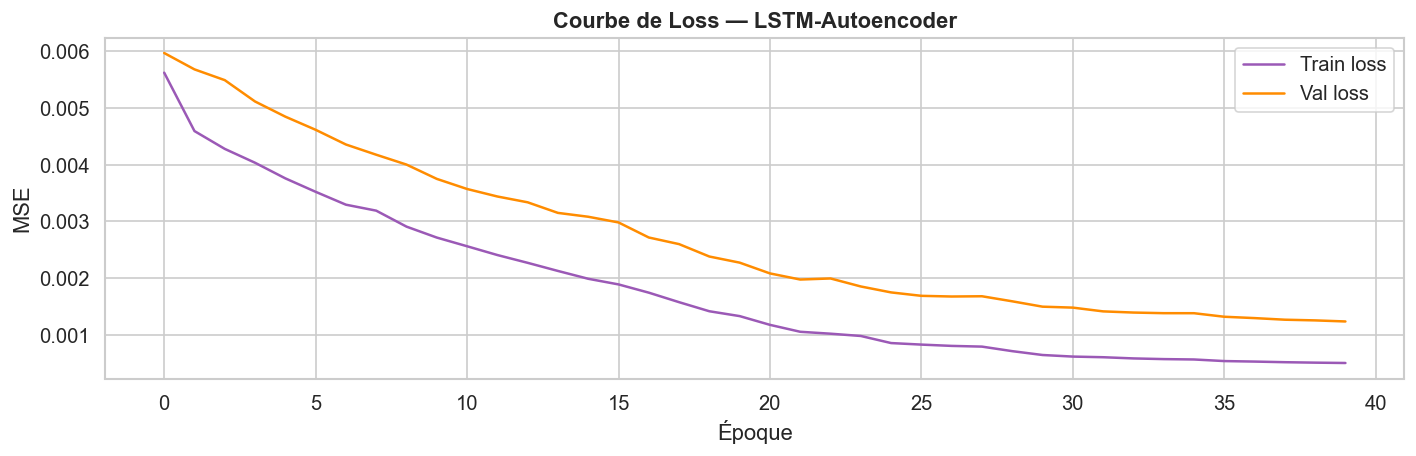

In [16]:
# ── Courbe de loss ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(history_ae.history['loss'],     label='Train loss', color='#9B59B6')
ax.plot(history_ae.history['val_loss'], label='Val loss',   color='darkorange')
ax.set_title('Courbe de Loss — LSTM-Autoencoder', fontweight='bold')
ax.set_xlabel('Époque')
ax.set_ylabel('MSE')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig33_ae_loss.png', bbox_inches='tight')
plt.show()

In [17]:
# ── Calcul des erreurs de reconstruction ──────────────────────────────────────
print('⏳ Calcul des erreurs de reconstruction...')

# Reconstruction de toutes les séquences
X_reconstructed = model_ae.predict(X_eval_ae, batch_size=256, verbose=0)

# Erreur de reconstruction : MSE par séquence
recon_errors = np.mean((X_eval_ae - X_reconstructed) ** 2, axis=(1, 2))

# Aligner les labels (les SEQ_LEN-1 premiers points n'ont pas de séquence complète)
# On associe l'erreur à la DERNIÈRE observation de chaque séquence
y_true_ae = df_feat['label_binary'].values[SEQ_LEN_AE - 1:]

print(f'✅ Erreurs calculées : {recon_errors.shape}')
print(f'   Labels alignés   : {y_true_ae.shape}')
print(f'   Erreur moyenne (normal)  : {recon_errors[y_true_ae == 0].mean():.6f}')
print(f'   Erreur moyenne (anomalie): {recon_errors[y_true_ae == 1].mean():.6f}')

⏳ Calcul des erreurs de reconstruction...
✅ Erreurs calculées : (277321,)
   Labels alignés   : (277321,)
   Erreur moyenne (normal)  : 0.009714
   Erreur moyenne (anomalie): 0.019675


In [18]:
# ── Seuil de détection LSTM-AE ───────────────────────────────────────────────
# On cherche le seuil qui maximise le F1-score sur les données d'entraînement normales
# Ici on utilise le percentile (ex: 95e percentile des erreurs normales du train)

# Erreurs sur données normales (train) pour calibrer le seuil
X_train_ae_recon = model_ae.predict(X_train_ae, batch_size=256, verbose=0)
train_recon_errors = np.mean((X_train_ae - X_train_ae_recon) ** 2, axis=(1, 2))

THRESHOLD_AE = np.percentile(train_recon_errors, 95)
print(f'📊 Seuil de détection (percentile 95 des erreurs normales) : {THRESHOLD_AE:.6f}')

# Prédiction binaire
y_pred_ae = (recon_errors > THRESHOLD_AE).astype(int)

metrics_ae = evaluate_detector(y_true_ae, y_pred_ae, 'LSTM-Autoencoder')
results_detection.append(metrics_ae)

📊 Seuil de détection (percentile 95 des erreurs normales) : 0.001952

📊 LSTM-Autoencoder
   Précision : 0.0836  (8.4%)
   Rappel    : 0.6338  (63.4%)
   F1-Score  : 0.1477

              precision    recall  f1-score   support

      Normal       0.98      0.71      0.82    266202
    Anomalie       0.08      0.63      0.15     11119

    accuracy                           0.71    277321
   macro avg       0.53      0.67      0.49    277321
weighted avg       0.94      0.71      0.80    277321



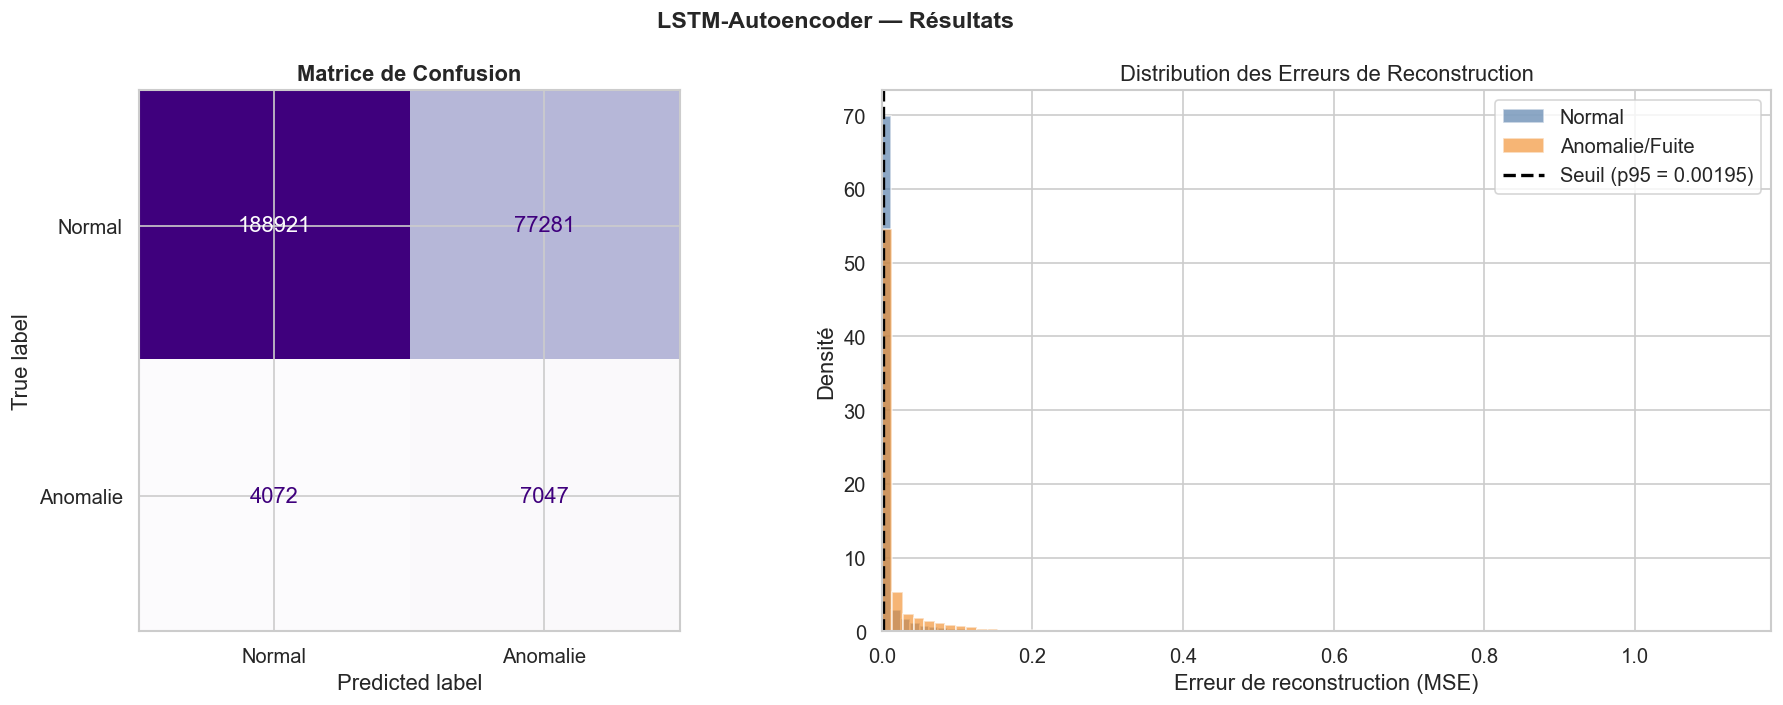

In [19]:
# ── Visualisation LSTM-AE ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('LSTM-Autoencoder — Résultats', fontsize=14, fontweight='bold')

# --- Matrice de confusion ---
ax = axes[0]
cm_ae = confusion_matrix(y_true_ae, y_pred_ae)
disp_ae = ConfusionMatrixDisplay(cm_ae, display_labels=['Normal', 'Anomalie'])
disp_ae.plot(ax=ax, colorbar=False, cmap='Purples')
ax.set_title('Matrice de Confusion', fontweight='bold')

# --- Distribution des erreurs de reconstruction ---
ax = axes[1]
ax.hist(recon_errors[y_true_ae == 0], bins=80, alpha=0.65,
        color=COLORS['normal'], label='Normal', density=True)
ax.hist(recon_errors[y_true_ae == 1], bins=80, alpha=0.65,
        color=COLORS['anomaly'], label='Anomalie/Fuite', density=True)
ax.axvline(THRESHOLD_AE, color='black', lw=2, ls='--',
           label=f'Seuil (p95 = {THRESHOLD_AE:.5f})')
ax.set_xlabel('Erreur de reconstruction (MSE)')
ax.set_ylabel('Densité')
ax.set_title('Distribution des Erreurs de Reconstruction')
ax.set_xlim(left=0)
ax.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig34_ae_resultats.png', bbox_inches='tight')
plt.show()

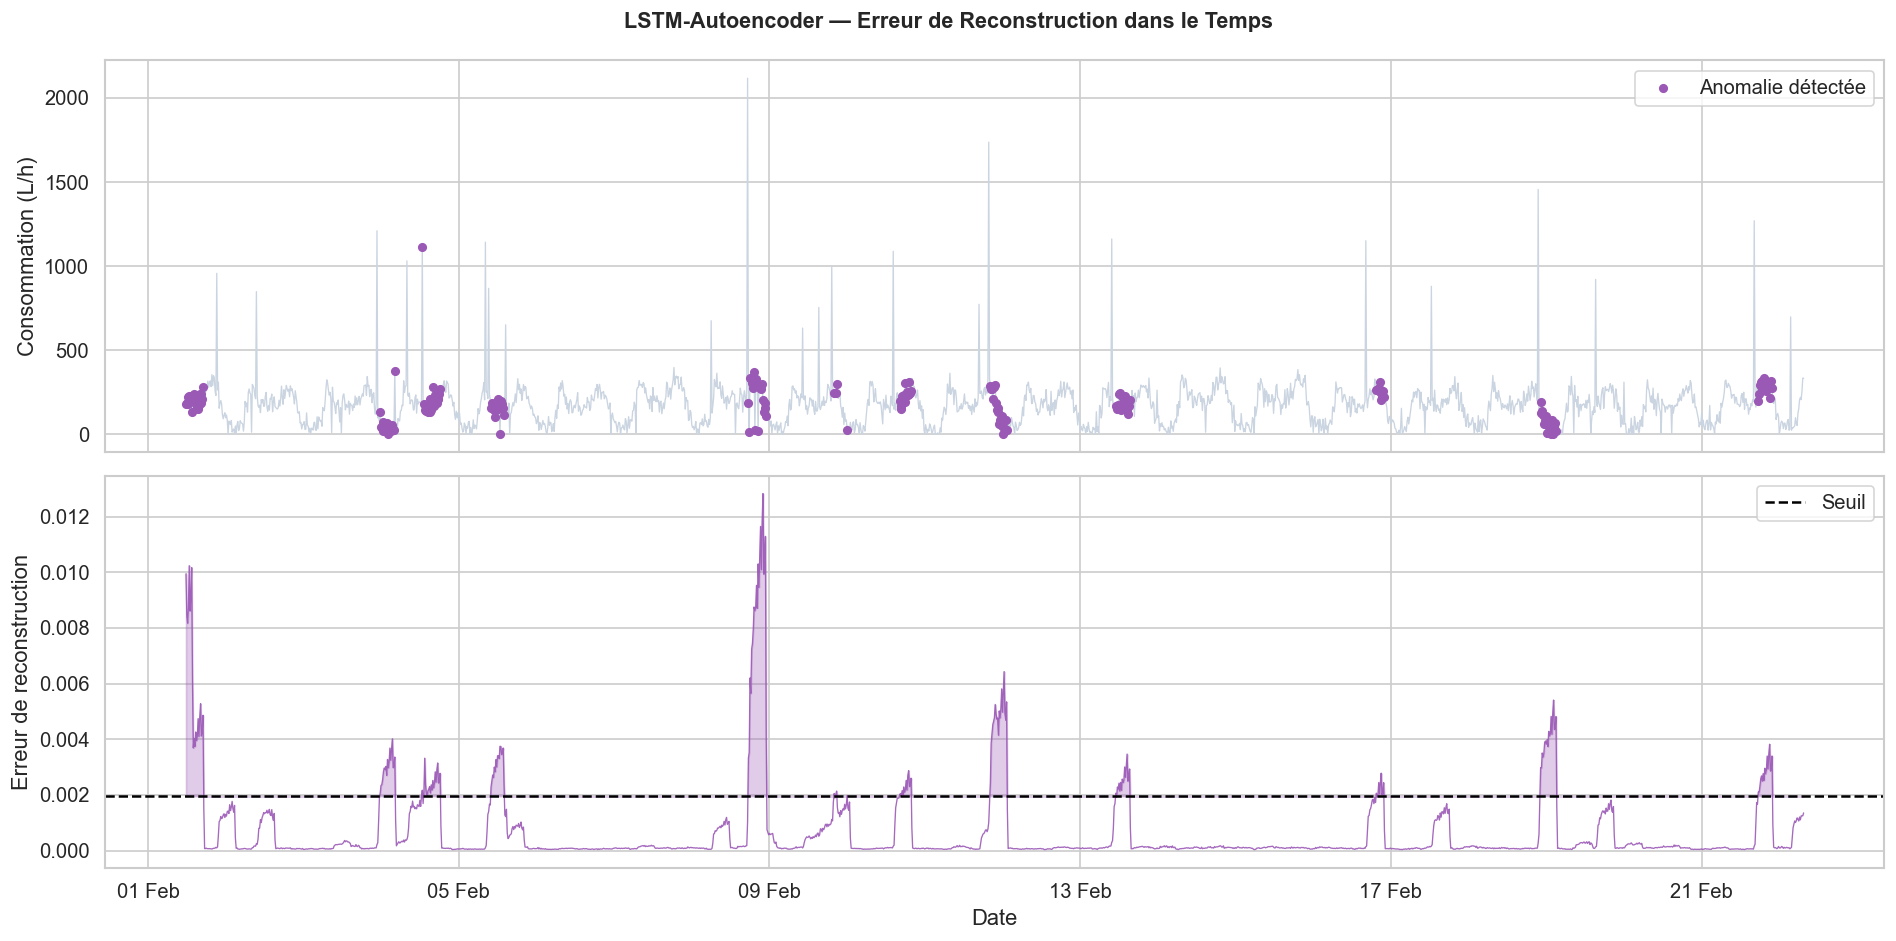

In [20]:
# ── Visualisation temporelle AE ───────────────────────────────────────────────
# Zoom sur les 2 000 derniers points pour la lisibilité
N_PLOT = 2000

df_ae_plot = df_feat.iloc[SEQ_LEN_AE - 1:].reset_index(drop=True)
n_plot = min(N_PLOT, len(df_ae_plot))

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
fig.suptitle('LSTM-Autoencoder — Erreur de Reconstruction dans le Temps', fontsize=13, fontweight='bold')

ax = axes[0]
ax.plot(df_ae_plot['timestamp'].values[:n_plot],
        df_ae_plot['consumptionliters'].values[:n_plot],
        color='#CBD5E1', linewidth=0.8, zorder=1)
# Anomalies détectées
detected = y_pred_ae[:n_plot] == 1
ax.scatter(df_ae_plot['timestamp'].values[:n_plot][detected],
           df_ae_plot['consumptionliters'].values[:n_plot][detected],
           color=COLORS['lstm_ae'], s=20, zorder=3, label='Anomalie détectée')
ax.set_ylabel('Consommation (L/h)')
ax.legend()

ax = axes[1]
ax.plot(df_ae_plot['timestamp'].values[:n_plot],
        recon_errors[:n_plot], color=COLORS['lstm_ae'], linewidth=0.8, alpha=0.9)
ax.axhline(THRESHOLD_AE, color='black', lw=1.5, ls='--', label='Seuil')
ax.fill_between(df_ae_plot['timestamp'].values[:n_plot],
                np.where(recon_errors[:n_plot] > THRESHOLD_AE,
                         recon_errors[:n_plot], THRESHOLD_AE),
                THRESHOLD_AE, color=COLORS['lstm_ae'], alpha=0.3)
ax.set_ylabel('Erreur de reconstruction')
ax.set_xlabel('Date')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig35_ae_serie_temporelle.png', bbox_inches='tight')
plt.show()

## 4. Modèle 3 — Méthode Statistique (3-Sigma sur Résidus STL)

**Principe :** On décompose la série temporelle de chaque compteur avec **STL** (Seasonal-Trend  
Decomposition using LOESS) pour extraire les résidus (ce qui reste après tendance + saisonnalité).  
Un point est anormal si son résidu dépasse **±3 écarts-types** (règle 3-sigma robuste).

- **Interprétable** : on peut expliquer pourquoi un point est anormal
- **Par compteur** : chaque DMA a son propre profil normal
- **Robuste** : on utilise la médiane et le MAD (Median Absolute Deviation) plutôt que la std classique


In [21]:
# ── Décomposition STL par compteur ───────────────────────────────────────────
print('⏳ Décomposition STL pour chaque compteur...')

residuals_all = []
y_true_sigma_all = []
timestamps_all = []
meter_ids_all = []

for meter_id in df_feat['meterid'].unique():
    df_m = df_feat[df_feat['meterid'] == meter_id].sort_values('timestamp').copy()
    
    if len(df_m) < 48:  # Besoin d'au moins 2 cycles pour STL
        continue
    
    series = df_m['consumptionliters'].values
    
    try:
        stl = STL(series, period=24, robust=True)
        stl_fit = stl.fit()
        residuals = stl_fit.resid
    except Exception as e:
        # Fallback : résidus bruts via moyenneglissante
        roll_mean = pd.Series(series).rolling(24, center=True, min_periods=1).mean().values
        residuals = series - roll_mean
    
    residuals_all.extend(residuals)
    y_true_sigma_all.extend(df_m['label_binary'].values)
    timestamps_all.extend(df_m['timestamp'].values)
    meter_ids_all.extend(df_m['meterid'].values)

residuals_all    = np.array(residuals_all)
y_true_sigma_all = np.array(y_true_sigma_all)
timestamps_all   = np.array(timestamps_all)

print(f'✅ STL terminé — {len(residuals_all):,} résidus calculés')

⏳ Décomposition STL pour chaque compteur...
✅ STL terminé — 277,344 résidus calculés


In [22]:
# ── Seuil 3-sigma robuste (MAD) ──────────────────────────────────────────────
# On utilise la médiane et MAD pour robustesse aux anomalies dans les résidus
median_resid = np.median(residuals_all)
mad_resid    = np.median(np.abs(residuals_all - median_resid))
robust_std   = 1.4826 * mad_resid  # facteur de consistance pour la distribution normale

THRESHOLD_SIGMA_POS = median_resid + 3 * robust_std
THRESHOLD_SIGMA_NEG = median_resid - 3 * robust_std

print(f'📊 Statistiques des résidus :')
print(f'   Médiane : {median_resid:.2f} L')
print(f'   MAD     : {mad_resid:.2f} L')
print(f'   Std robuste (1.4826*MAD) : {robust_std:.2f} L')
print(f'\n   Seuil HAUT (+ 3σ) : {THRESHOLD_SIGMA_POS:.2f} L')
print(f'   Seuil BAS  (- 3σ) : {THRESHOLD_SIGMA_NEG:.2f} L')

# Prédiction : anormal si résidu hors de [−3σ, +3σ]
y_pred_sigma = ((residuals_all > THRESHOLD_SIGMA_POS) |
                (residuals_all < THRESHOLD_SIGMA_NEG)).astype(int)

metrics_sigma = evaluate_detector(y_true_sigma_all, y_pred_sigma, 'Méthode 3-Sigma (STL)')
results_detection.append(metrics_sigma)

📊 Statistiques des résidus :
   Médiane : -0.07 L
   MAD     : 53.00 L
   Std robuste (1.4826*MAD) : 78.58 L

   Seuil HAUT (+ 3σ) : 235.65 L
   Seuil BAS  (- 3σ) : -235.80 L

📊 Méthode 3-Sigma (STL)
   Précision : 0.2196  (22.0%)
   Rappel    : 0.6280  (62.8%)
   F1-Score  : 0.3254

              precision    recall  f1-score   support

      Normal       0.98      0.91      0.94    266221
    Anomalie       0.22      0.63      0.33     11123

    accuracy                           0.90    277344
   macro avg       0.60      0.77      0.63    277344
weighted avg       0.95      0.90      0.92    277344



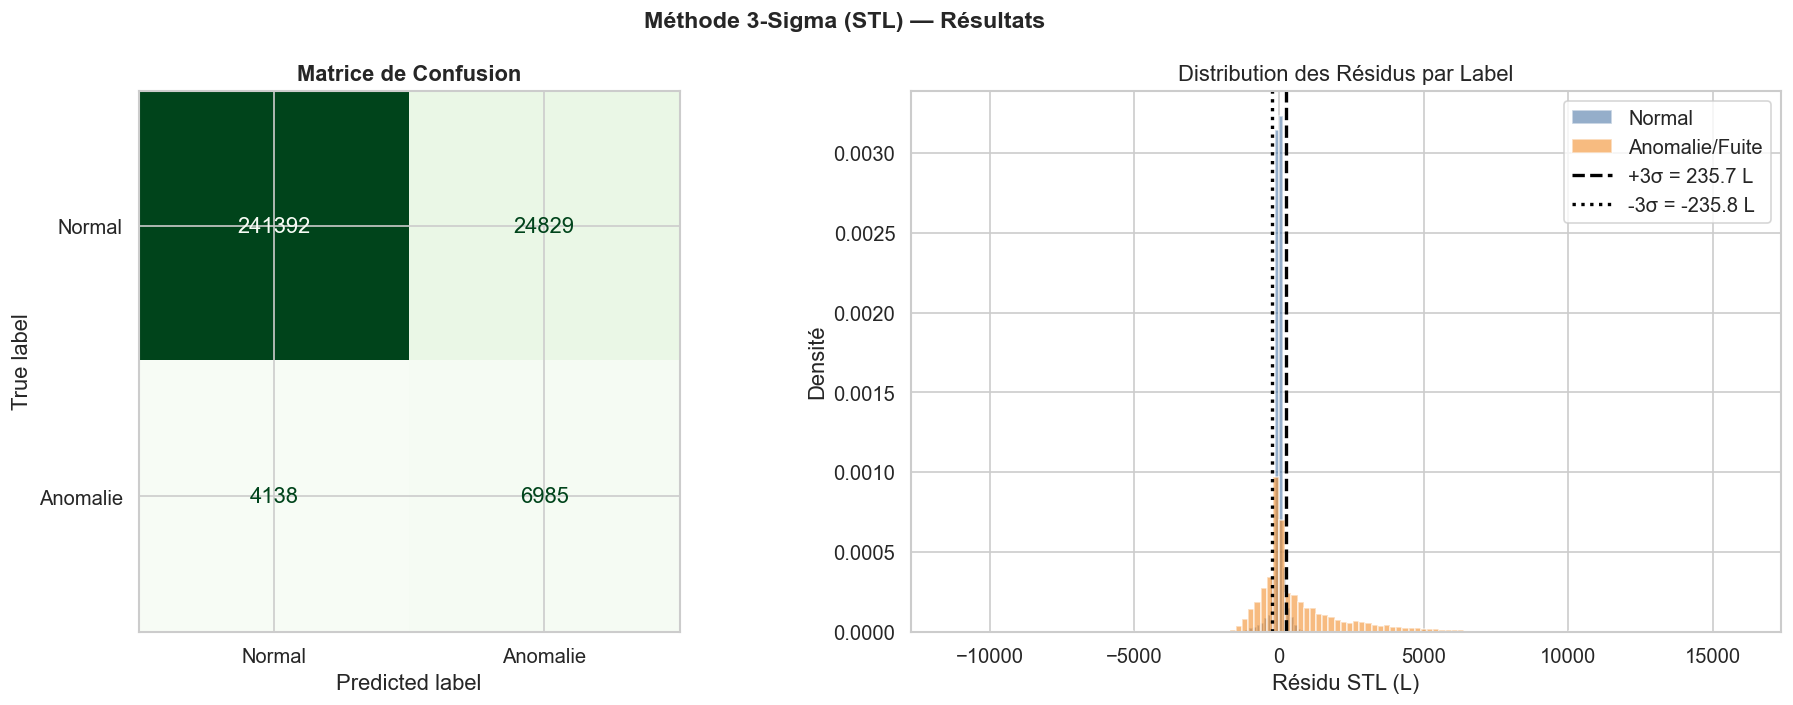

In [23]:
# ── Visualisation Méthode 3-Sigma ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Méthode 3-Sigma (STL) — Résultats', fontsize=14, fontweight='bold')

# --- Matrice de confusion ---
ax = axes[0]
cm_s = confusion_matrix(y_true_sigma_all, y_pred_sigma)
disp_s = ConfusionMatrixDisplay(cm_s, display_labels=['Normal', 'Anomalie'])
disp_s.plot(ax=ax, colorbar=False, cmap='Greens')
ax.set_title('Matrice de Confusion', fontweight='bold')

# --- Distribution des résidus ---
ax = axes[1]
ax.hist(residuals_all[y_true_sigma_all == 0], bins=100, alpha=0.6,
        color=COLORS['normal'], label='Normal', density=True)
ax.hist(residuals_all[y_true_sigma_all == 1], bins=100, alpha=0.6,
        color=COLORS['anomaly'], label='Anomalie/Fuite', density=True)
ax.axvline(THRESHOLD_SIGMA_POS, color='black', lw=2, ls='--',
           label=f'+3σ = {THRESHOLD_SIGMA_POS:.1f} L')
ax.axvline(THRESHOLD_SIGMA_NEG, color='black', lw=2, ls=':',
           label=f'-3σ = {THRESHOLD_SIGMA_NEG:.1f} L')
ax.set_xlabel('Résidu STL (L)')
ax.set_ylabel('Densité')
ax.set_title('Distribution des Résidus par Label')
ax.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig36_sigma3_resultats.png', bbox_inches='tight')
plt.show()

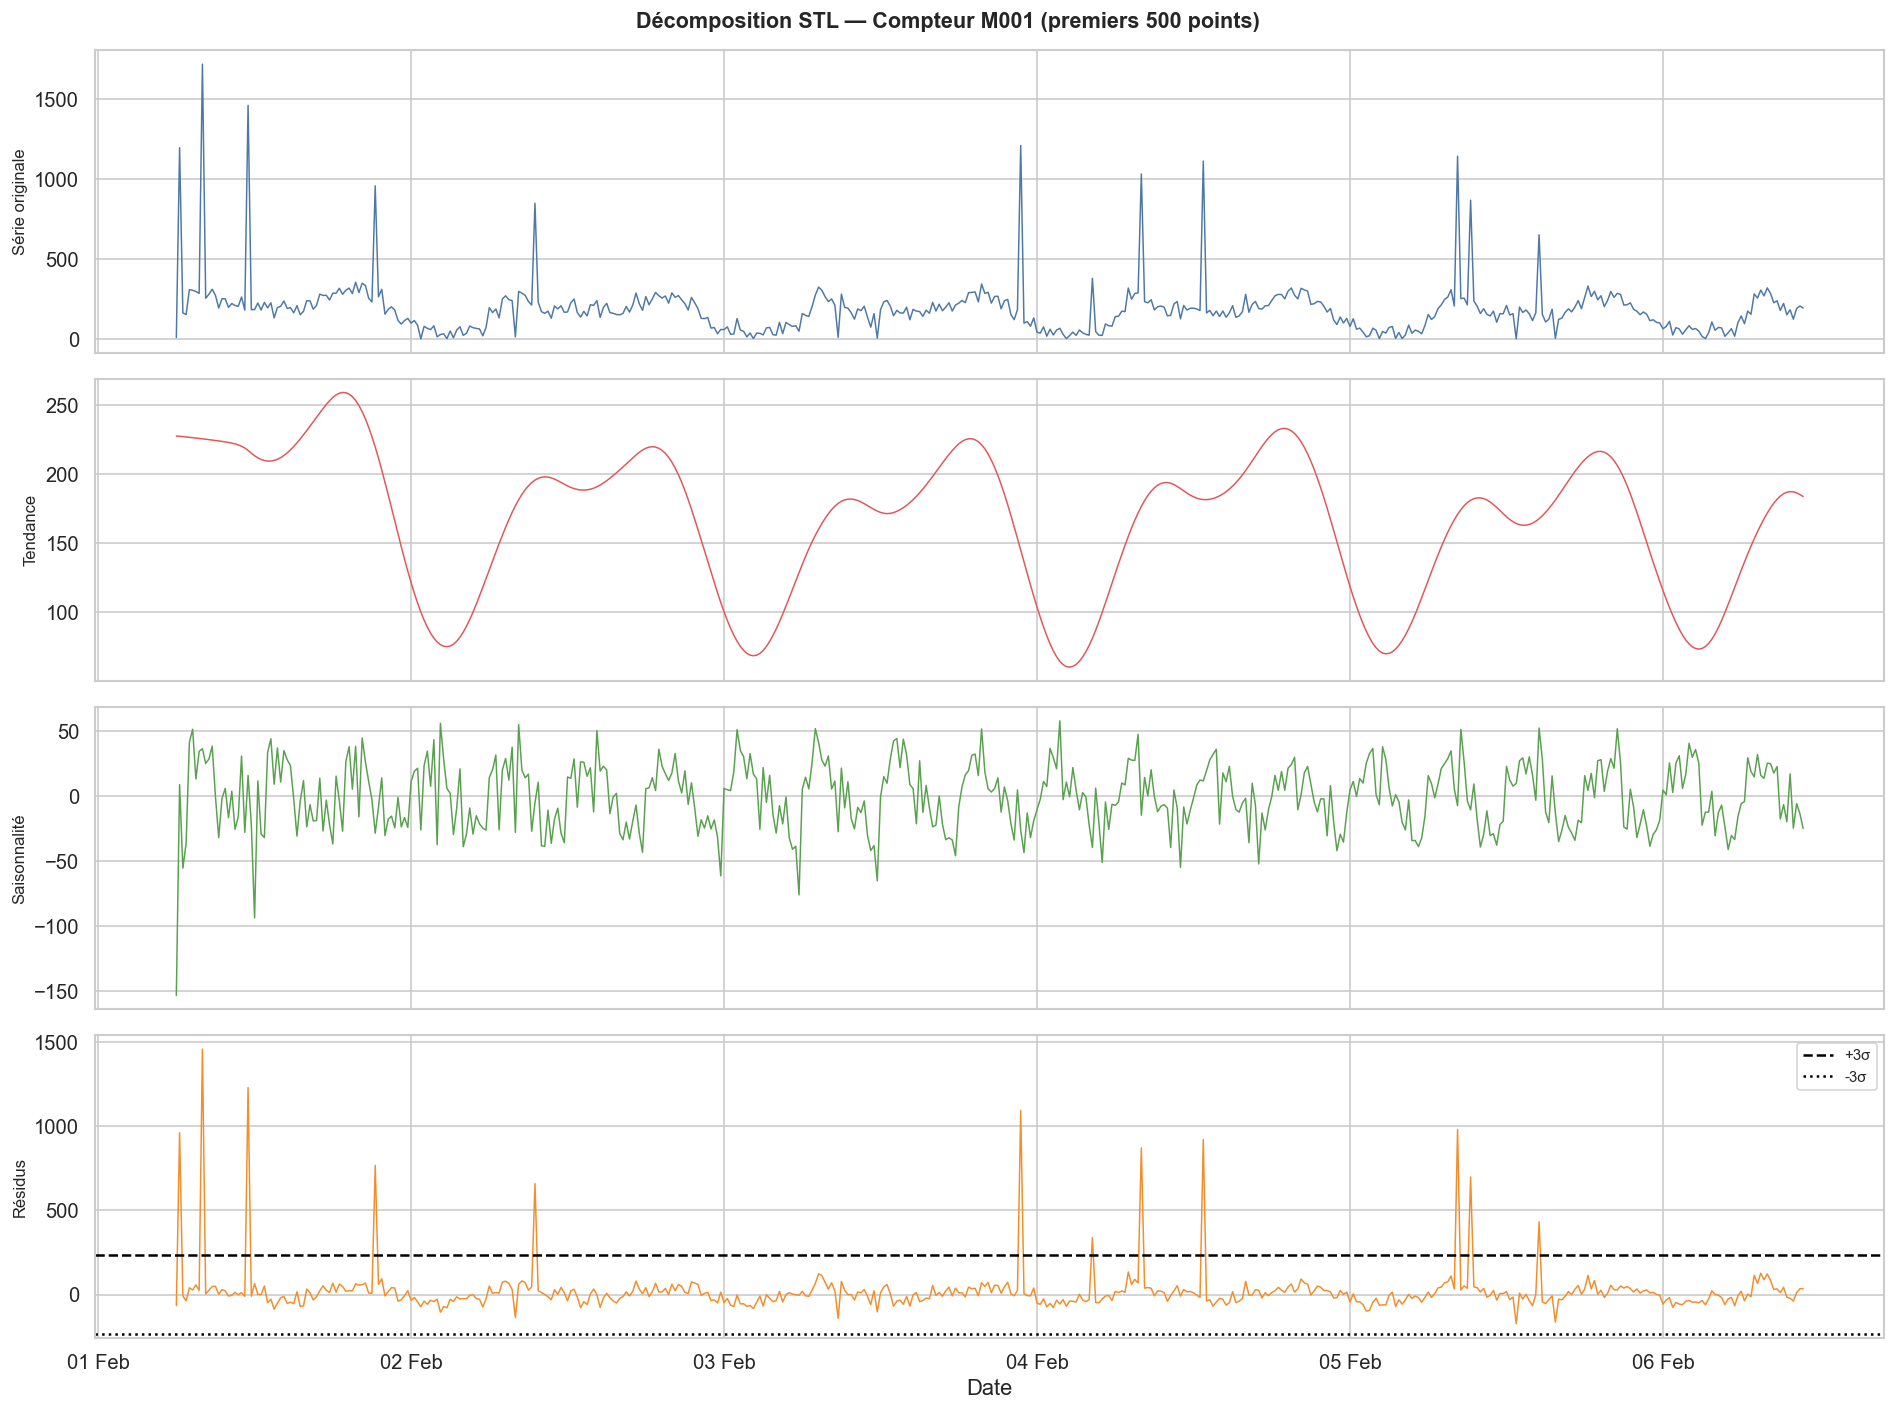

In [24]:
# ── Visualisation STL : décomposition d'un compteur ──────────────────────────
sample_m = df_feat['meterid'].unique()[0]
df_m_plot = df_feat[df_feat['meterid'] == sample_m].sort_values('timestamp').copy()
series_m = df_m_plot['consumptionliters'].values

stl_m = STL(series_m, period=24, robust=True).fit()

# Zoom sur les 500 premiers points
N_STL = 500
fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)
fig.suptitle(f'Décomposition STL — Compteur {sample_m} (premiers {N_STL} points)',
             fontsize=13, fontweight='bold')

components = [
    (series_m[:N_STL],         'Série originale',  '#4E79A7'),
    (stl_m.trend[:N_STL],      'Tendance',         '#E15759'),
    (stl_m.seasonal[:N_STL],   'Saisonnalité',     '#59A14F'),
    (stl_m.resid[:N_STL],      'Résidus',          '#F28E2B'),
]

for ax, (data, title, color) in zip(axes, components):
    ax.plot(df_m_plot['timestamp'].values[:N_STL], data, color=color, linewidth=0.9)
    ax.set_ylabel(title, fontsize=10)
    if title == 'Résidus':
        ax.axhline(THRESHOLD_SIGMA_POS, color='black', lw=1.5, ls='--', label='+3σ')
        ax.axhline(THRESHOLD_SIGMA_NEG, color='black', lw=1.5, ls=':', label='-3σ')
        ax.legend(fontsize=9)

axes[-1].set_xlabel('Date')
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig37_stl_decomposition.png', bbox_inches='tight')
plt.show()

## 5. Comparaison des 3 Modèles

In [25]:
# ── Tableau comparatif ────────────────────────────────────────────────────────
df_results = pd.DataFrame(results_detection).set_index('model')
df_results = df_results.sort_values('F1', ascending=False)

print('\n' + '='*60)
print('      COMPARAISON DES MODÈLES DE DÉTECTION')
print('='*60)
print(f'{"Modèle":<30} {"Précision":>10} {"Rappel":>8} {"F1":>8}')
print('-'*60)
for model, row in df_results.iterrows():
    print(f'{model:<30} {row["Précision"]:>9.1%} {row["Rappel"]:>7.1%} {row["F1"]:>7.4f}')
print('='*60)
best_detector = df_results.index[0]
print(f'\n🏆 Meilleur modèle (F1) : {best_detector}')


      COMPARAISON DES MODÈLES DE DÉTECTION
Modèle                          Précision   Rappel       F1
------------------------------------------------------------
Isolation Forest                   31.1%   40.9%  0.3532
Méthode 3-Sigma (STL)              22.0%   62.8%  0.3254
LSTM-Autoencoder                    8.4%   63.4%  0.1477

🏆 Meilleur modèle (F1) : Isolation Forest


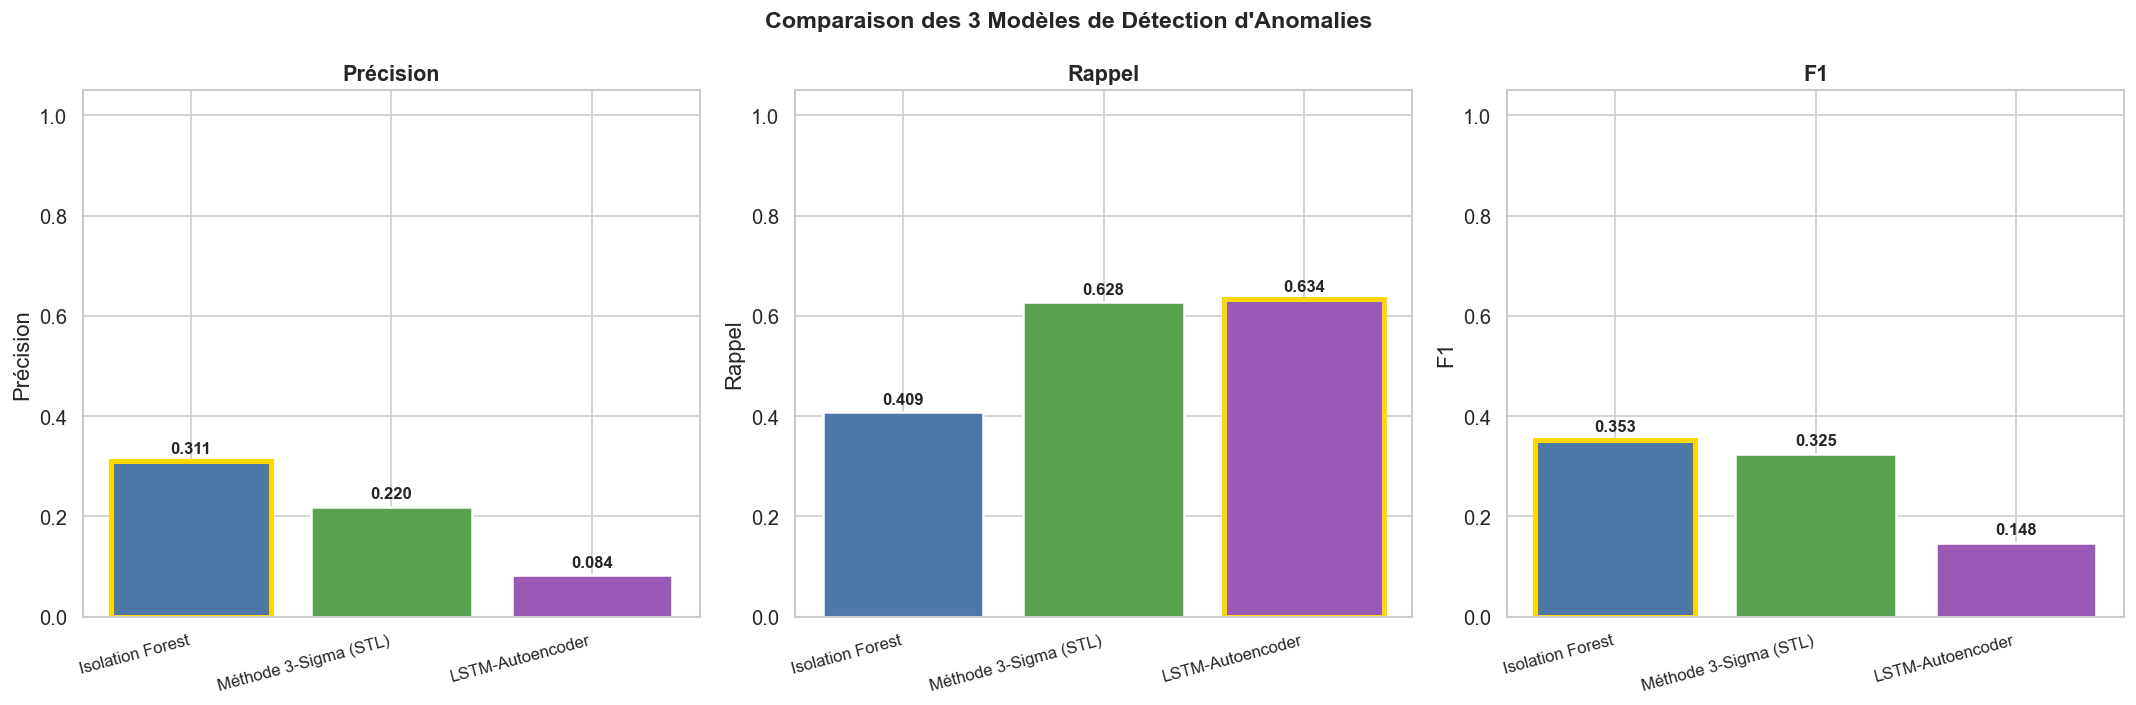

In [26]:
# ── Graphique comparatif ─────────────────────────────────────────────────────
model_colors_det = {
    'Isolation Forest':         COLORS['if'],
    'LSTM-Autoencoder':         COLORS['lstm_ae'],
    'Méthode 3-Sigma (STL)':   COLORS['sigma3'],
}
bar_colors = [model_colors_det.get(m, '#888') for m in df_results.index]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Comparaison des 3 Modèles de Détection d\'Anomalies',
             fontsize=14, fontweight='bold')

for ax, metric in zip(axes, ['Précision', 'Rappel', 'F1']):
    bars = ax.bar(range(len(df_results)), df_results[metric].values,
                  color=bar_colors, edgecolor='white', linewidth=1.5)
    ax.set_xticks(range(len(df_results)))
    ax.set_xticklabels(df_results.index, rotation=15, ha='right', fontsize=10)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.set_ylabel(metric)
    # Annoter les valeurs
    for i, v in enumerate(df_results[metric].values):
        ax.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom',
                fontsize=10, fontweight='bold')
    # Mettre en évidence le meilleur
    best_idx = df_results[metric].values.argmax()
    bars[best_idx].set_edgecolor('gold')
    bars[best_idx].set_linewidth(3)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig38_comparaison_detecteurs.png', bbox_inches='tight')
plt.show()

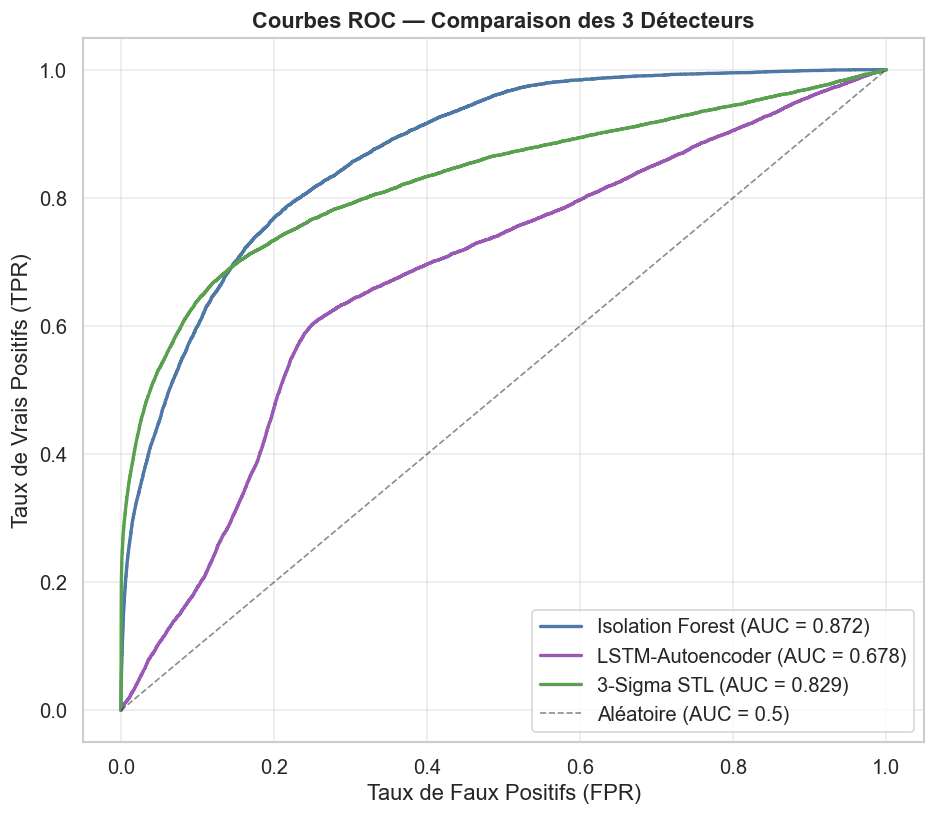


📊 AUC-ROC :
   Isolation Forest  : 0.8722
   LSTM-Autoencoder  : 0.6780
   3-Sigma STL       : 0.8292


In [27]:
# ── Courbes ROC comparatives ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))

# Isolation Forest
fpr_if, tpr_if, _ = roc_curve(y_true_if, scores_if)
auc_if = roc_auc_score(y_true_if, scores_if)
ax.plot(fpr_if, tpr_if, color=COLORS['if'], lw=2,
        label=f'Isolation Forest (AUC = {auc_if:.3f})')

# LSTM-AE
fpr_ae, tpr_ae, _ = roc_curve(y_true_ae, recon_errors)
auc_ae = roc_auc_score(y_true_ae, recon_errors)
ax.plot(fpr_ae, tpr_ae, color=COLORS['lstm_ae'], lw=2,
        label=f'LSTM-Autoencoder (AUC = {auc_ae:.3f})')

# 3-Sigma (score = |résidu| normalisé)
score_sigma = np.abs(residuals_all - median_resid) / (robust_std + 1e-8)
fpr_s, tpr_s, _ = roc_curve(y_true_sigma_all, score_sigma)
auc_s = roc_auc_score(y_true_sigma_all, score_sigma)
ax.plot(fpr_s, tpr_s, color=COLORS['sigma3'], lw=2,
        label=f'3-Sigma STL (AUC = {auc_s:.3f})')

# Diagonale (aléatoire)
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Aléatoire (AUC = 0.5)')

ax.set_xlabel('Taux de Faux Positifs (FPR)')
ax.set_ylabel('Taux de Vrais Positifs (TPR)')
ax.set_title('Courbes ROC — Comparaison des 3 Détecteurs', fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig39_courbes_roc.png', bbox_inches='tight')
plt.show()

print(f'\n📊 AUC-ROC :')
print(f'   Isolation Forest  : {auc_if:.4f}')
print(f'   LSTM-Autoencoder  : {auc_ae:.4f}')
print(f'   3-Sigma STL       : {auc_s:.4f}')

In [28]:
# ── Analyse fuites vs anomalies ───────────────────────────────────────────────
# Détail : le meilleur modèle détecte-t-il mieux les fuites ou les anomalies ?
print(f'\n=== ANALYSE DÉTAILLÉE PAR TYPE (Meilleur modèle : {best_detector}) ===')

if best_detector == 'Isolation Forest':
    y_pred_best = y_pred_if
    y_true_best = y_true_if
    df_eval = df_feat.copy()
elif best_detector == 'LSTM-Autoencoder':
    y_pred_best = y_pred_ae
    y_true_best = y_true_ae
    df_eval = df_feat.iloc[SEQ_LEN_AE - 1:].reset_index(drop=True).copy()
else:
    y_pred_best = y_pred_sigma
    y_true_best = y_true_sigma_all
    df_eval = pd.DataFrame({LABEL_COL: df_feat[LABEL_COL].values})

# Récupérer le label multiclasse pour les éléments évalués
labels_multi = df_eval[LABEL_COL].values[:len(y_pred_best)]

# F1 par classe
for lbl in ['anomaly', 'leak']:
    mask = (labels_multi == lbl) | (labels_multi == 'normal')
    if mask.sum() > 100:
        y_t_lbl = (labels_multi[mask] == lbl).astype(int)
        y_p_lbl = y_pred_best[mask]
        f1_lbl  = f1_score(y_t_lbl, y_p_lbl, zero_division=0)
        rec_lbl = recall_score(y_t_lbl, y_p_lbl, zero_division=0)
        print(f'\n  {lbl.capitalize():<10} : F1={f1_lbl:.3f}  Rappel={rec_lbl:.3f}')


=== ANALYSE DÉTAILLÉE PAR TYPE (Meilleur modèle : Isolation Forest) ===

  Anomaly    : F1=0.287  Rappel=0.411

  Leak       : F1=0.212  Rappel=0.406


## 6. Sauvegarde des Modèles

In [29]:
# ── Sauvegarde de tous les modèles + le meilleur ──────────────────────────────
print('💾 Sauvegarde des modèles...')

# Isolation Forest
joblib.dump(model_if,    MODEL_DIR / 'isolation_forest_detector.pkl')
joblib.dump(scaler_if,   MODEL_DIR / 'isolation_forest_scaler.pkl')
joblib.dump(IF_FEATURES, MODEL_DIR / 'isolation_forest_features.pkl')
print('   ✅ isolation_forest_detector.pkl + scaler + features')

# LSTM-Autoencoder
model_ae.save(MODEL_DIR / 'lstm_autoencoder_detector.h5')
joblib.dump(scaler_ae,      MODEL_DIR / 'lstm_ae_scaler.pkl')
joblib.dump(THRESHOLD_AE,   MODEL_DIR / 'lstm_ae_threshold.pkl')
print('   ✅ lstm_autoencoder_detector.h5 + scaler + threshold')

# 3-Sigma
sigma_params = {
    'median':              median_resid,
    'mad':                 mad_resid,
    'robust_std':          robust_std,
    'threshold_pos':       THRESHOLD_SIGMA_POS,
    'threshold_neg':       THRESHOLD_SIGMA_NEG,
}
joblib.dump(sigma_params, MODEL_DIR / 'sigma3_params.pkl')
print('   ✅ sigma3_params.pkl')

# Meilleur modèle → best_detector
if best_detector == 'Isolation Forest':
    joblib.dump(model_if, MODEL_DIR / 'best_detector.pkl')
    joblib.dump({'type': 'isolation_forest', 'features': IF_FEATURES,
                 'scaler': scaler_if}, MODEL_DIR / 'best_detector_meta.pkl')
elif best_detector == 'LSTM-Autoencoder':
    model_ae.save(MODEL_DIR / 'best_detector.h5')
    joblib.dump({'type': 'lstm_ae', 'features': AE_FEATURES,
                 'scaler': scaler_ae, 'threshold': THRESHOLD_AE,
                 'seq_len': SEQ_LEN_AE}, MODEL_DIR / 'best_detector_meta.pkl')
else:
    joblib.dump(sigma_params, MODEL_DIR / 'best_detector.pkl')
    joblib.dump({'type': 'sigma3', 'params': sigma_params},
                MODEL_DIR / 'best_detector_meta.pkl')

# Résultats
df_results.to_csv(MODEL_DIR / 'detection_results.csv')
print('   ✅ detection_results.csv')

print(f'\n🏆 Meilleur détecteur sauvegardé : {best_detector}')
print(f'   → models/best_detector.*')

💾 Sauvegarde des modèles...


   ✅ isolation_forest_detector.pkl + scaler + features
   ✅ lstm_autoencoder_detector.h5 + scaler + threshold
   ✅ sigma3_params.pkl
   ✅ detection_results.csv

🏆 Meilleur détecteur sauvegardé : Isolation Forest
   → models/best_detector.*


## 7. Synthèse & Recommandations pour le Backend

In [30]:
# ── Récapitulatif final ───────────────────────────────────────────────────────
auc_dict = {
    'Isolation Forest':       auc_if,
    'LSTM-Autoencoder':       auc_ae,
    'Méthode 3-Sigma (STL)': auc_s,
}

print("""
╔══════════════════════════════════════════════════════════════════════╗
║         SYNTHÈSE — NOTEBOOK 03 DÉTECTION D'ANOMALIES               ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  3 MODÈLES ENTRAÎNÉS ET COMPARÉS                                    ║
║                                                                      ║
║  Isolation Forest                                                    ║
║  → Features : consommation, débit, pression + lags + déviation     ║
║  → Entraîné sur données TRAIN uniquement                            ║
║  → Rapide et non-paramétrique                                        ║
║                                                                      ║
║  LSTM-Autoencoder                                                    ║
║  → Entraîné UNIQUEMENT sur les données normales                     ║
║  → Seuil = percentile 95 des erreurs de reconstruction normales    ║
║  → Architecture : LSTM(64) → RepeatVector → LSTM(64) → Dense      ║
║                                                                      ║
║  Méthode 3-Sigma (STL)                                              ║
║  → Décomposition STL (période=24h) par compteur                    ║
║  → Seuil robuste basé sur MAD (résistant aux outliers)             ║
║  → Interprétable : résidu = ce qui ne s'explique pas par           ║
║    la tendance + saisonnalité                                       ║
║                                                                      ║
║  MODÈLES SAUVEGARDÉS → models/                                      ║
║  FIGURES SAUVEGARDÉES → reports/figures/ (fig31 à fig39)            ║
║                                                                      ║
╚══════════════════════════════════════════════════════════════════════╝
""")

print('📊 Résultats finaux :')
# Ajouter l'AUC au tableau
df_results['AUC-ROC'] = df_results.index.map(auc_dict)
print(df_results.round(4).to_string())
print(f'\n🏆 Meilleur modèle (F1) : {best_detector}')
print('\n🏁 Notebook 03 terminé.')
print('   Prochaine étape → Backend FastAPI (backend/main.py)')
print('   Endpoints à implémenter : /predict  /anomalies  /health')


╔══════════════════════════════════════════════════════════════════════╗
║         SYNTHÈSE — NOTEBOOK 03 DÉTECTION D'ANOMALIES               ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  3 MODÈLES ENTRAÎNÉS ET COMPARÉS                                    ║
║                                                                      ║
║  Isolation Forest                                                    ║
║  → Features : consommation, débit, pression + lags + déviation     ║
║  → Entraîné sur données TRAIN uniquement                            ║
║  → Rapide et non-paramétrique                                        ║
║                                                                      ║
║  LSTM-Autoencoder                                                    ║
║  → Entraîné UNIQUEMENT sur les données normales                     ║
║  → Seuil = percentile 95 des erreurs de reconstruction 